<a href="https://colab.research.google.com/github/kayorde25/nlp-twitter-sentiment-analysis/blob/main/nlp_twitter_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Twitter US Airline Sentiment Analysis

## Project Overview
This project applies Natural Language Processing (NLP) techniques to classify tweets about major U.S. airlines into three sentiment categories:

- Positive
- Neutral
- Negative

The objective is to preprocess tweet text, convert the text into numerical features, build machine learning models, and evaluate their performance.

## Import Required Libraries

In this step, we import the libraries needed for:

- data handling
- text preprocessing
- visualization
- machine learning
- model evaluation

In [57]:
# Import pandas for data loading and data manipulation
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import re for regular expression-based text cleaning
import re

# Import matplotlib.pyplot for plotting charts
import matplotlib.pyplot as plt

# Import seaborn for statistical visualization
import seaborn as sns

# Import nltk for natural language processing tasks
import nltk

## Download NLP Resources

We download the NLTK resources needed for:

- stopword removal
- lemmatization

In [58]:
# Download the English stopwords corpus from NLTK
nltk.download('stopwords')

# Download the WordNet lexical database used for lemmatization
nltk.download('wordnet')

# Download additional WordNet language data
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Import NLP and Machine Learning Components

Now we import the specific tools needed for:

- stopword handling
- lemmatization
- splitting the dataset
- text vectorization
- model building
- evaluation

In [59]:
# Import English stopwords from nltk
from nltk.corpus import stopwords

# Import the WordNet lemmatizer from nltk
from nltk.stem import WordNetLemmatizer

# Import train_test_split to divide the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import CountVectorizer for Bag of Words feature extraction
from sklearn.feature_extraction.text import CountVectorizer

# Import TfidfVectorizer for TF-IDF feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Import Pipeline to combine preprocessing and model steps
from sklearn.pipeline import Pipeline

# Import accuracy_score to evaluate prediction accuracy
from sklearn.metrics import accuracy_score

# Import classification_report to view precision, recall, and F1-score
from sklearn.metrics import classification_report

# Import confusion_matrix to summarize prediction results
from sklearn.metrics import confusion_matrix

# Import LogisticRegression for classification modeling
from sklearn.linear_model import LogisticRegression

# Import MultinomialNB for Naive Bayes classification
from sklearn.naive_bayes import MultinomialNB

# Import LinearSVC for Support Vector Machine classification
from sklearn.svm import LinearSVC

## Load the Dataset

In this step, we load the Twitter airline sentiment dataset into a pandas DataFrame.

## Reproducible Dataset Setup (Colab + GitHub)

This project automatically downloads the dataset from Kaggle when run.



In [60]:
!kaggle datasets download -d crowdflower/twitter-airline-sentiment -p data

Dataset URL: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment
License(s): CC-BY-NC-SA-4.0
twitter-airline-sentiment.zip: Skipping, found more recently modified local copy (use --force to force download)


## Load Tweets.csv (Robust Method)

This block directly targets the known dataset file (`Tweets.csv`) and includes fallback logic to handle nested extraction paths.

In [61]:
import os
import pandas as pd
import zipfile

# Expected filename
TARGET_FILE = "Tweets.csv"
DOWNLOAD_DIR = "data"

# Construct the path to the downloaded zip file
zip_file_path = os.path.join(DOWNLOAD_DIR, "twitter-airline-sentiment.zip")

# Check if the zip file exists and extract it if it does
if os.path.exists(zip_file_path):
    print(f"Extracting {zip_file_path}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(DOWNLOAD_DIR)
    print("Extraction complete.")
else:
    print(f"Zip file not found at: {zip_file_path}")

# Try common locations first
possible_paths = [
    os.path.join("data", TARGET_FILE),
    os.path.join("data", "twitter-airline-sentiment", TARGET_FILE) # This path is often created after unzipping
]

csv_path = None

# Check known paths
for path in possible_paths:
    if os.path.exists(path):
        csv_path = path
        break

# Fallback: search entire directory
if csv_path is None:
    for root, _, files in os.walk(DOWNLOAD_DIR):
        if TARGET_FILE in files:
            csv_path = os.path.join(root, TARGET_FILE)
            break

# Final validation
if csv_path is None:
    print("Directory structure:")
    for root, dirs, files in os.walk(DOWNLOAD_DIR):
        print(root, files)
    raise FileNotFoundError("Tweets.csv not found after extraction.")

print("Found CSV at:", csv_path)

# Load dataset
df = pd.read_csv(csv_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)
print(df.head())

Extracting data/twitter-airline-sentiment.zip...
Extraction complete.
Found CSV at: data/Tweets.csv
Dataset loaded successfully
Shape: (14640, 15)
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        nam

###Exploratory Data Analysis and Preprocessing

#### Exploratory Data Analysis (EDA)

This section explores the structure, distribution, and quality of the dataset before modeling.

Key objectives:

- Understand dataset shape and structure  
- Inspect sentiment distribution  
- Identify missing values  
- Explore text characteristics  

In [62]:
# Display dataset shape
print("Shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns.tolist())

# Preview data
df.head()

Shape: (14640, 15)

Columns:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## Target Distribution

Analyze the distribution of sentiment labels to understand class balance.

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


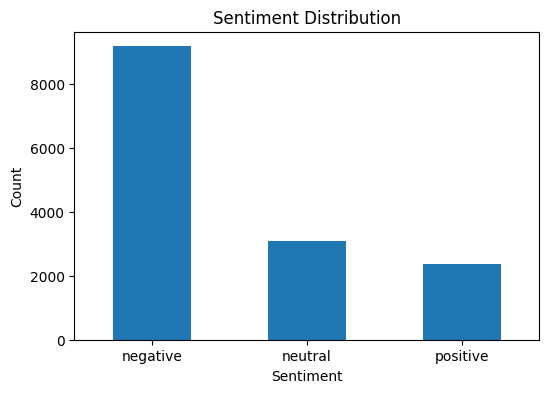

In [63]:
import matplotlib.pyplot as plt

# Count sentiment labels
sentiment_counts = df["airline_sentiment"].value_counts()

print(sentiment_counts)

# Plot distribution
plt.figure(figsize=(6,4))
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Insight

- The dataset typically shows class imbalance (more negative tweets)
- This can influence model performance and should be considered during modeling

## Missing Values Analysis

Check for missing or null values in key columns.

In [64]:
# Check missing values
print(df.isnull().sum())

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64


### Insight

- Missing values in the text column must be handled before preprocessing
- Rows with missing text will be removed

## Text Cleaning

Prepare raw tweet text for modeling by:

- Lowercasing text  
- Removing URLs  
- Removing mentions (@user)  
- Removing special characters  
- Removing extra whitespace  

In [65]:
import re

def clean_text(text):
    """
    Clean tweet text for NLP processing.
    """

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags (optional: keep words instead)
    text = re.sub(r'#', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [66]:
# Remove rows with missing text
df = df.dropna(subset=["text"])

# Apply cleaning function
df["clean_text"] = df["text"].apply(clean_text)

# Preview cleaned data
df[["text", "clean_text"]].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


## Text Length Analysis

Analyze the distribution of tweet lengths after cleaning.

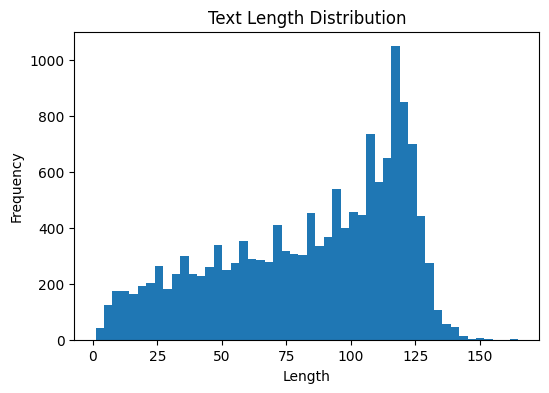

In [67]:
# Compute text length
df["text_length"] = df["clean_text"].apply(len)

# Plot distribution
plt.figure(figsize=(6,4))
plt.hist(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

### Insight

- Tweets are short, typically under 150 characters
- This influences model choice (TF-IDF, embeddings, etc.)

## Label Encoding

Convert sentiment labels into numerical format for modeling.

In [68]:
from sklearn.preprocessing import LabelEncoder

# Encode target variable
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["airline_sentiment"])

# Store class names
class_names = list(label_encoder.classes_)

print("Classes:", class_names)

Classes: ['negative', 'neutral', 'positive']


## Train-Test Split

Split the dataset into training and testing sets.

In [69]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (11712,)
Test size: (2928,)


## Text Vectorization (TF-IDF)

Convert text into numerical features using TF-IDF.

In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

# Fit and transform training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

TF-IDF shape (train): (11712, 5000)
TF-IDF shape (test): (2928, 5000)


### Insight

- TF-IDF converts text into numerical features
- Bigrams (1,2) capture short phrase patterns
- Limiting features to 5000 reduces noise and improves efficiency

## Baseline Models

In this section, we train and evaluate multiple classical machine learning models for sentiment classification.

Models included:

- Logistic Regression  
- Multinomial Naive Bayes  
- Linear Support Vector Machine (SVM)  

These models provide strong baselines for text classification tasks using TF-IDF features.

### Train Baseline Models

In [71]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

# Train all models
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model

print("All models trained successfully.")

Training Logistic Regression...
Training Naive Bayes...
Training Linear SVM...
All models trained successfully.


## Evaluate Models

In [72]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(name, model, X_test, y_test):
    """
    Evaluate a model and print performance metrics.
    """

    # Generate predictions
    y_pred = model.predict(X_test)

    # Compute accuracy
    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy: {acc:.4f}")

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return acc, y_pred

In [73]:
results = {}
predictions = {}

for name, model in trained_models.items():
    acc, y_pred = evaluate_model(name, model, X_test_tfidf, y_test)
    results[name] = acc
    predictions[name] = y_pred


Logistic Regression
----------------------------------------
Accuracy: 0.7937

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.87      1835
           1       0.67      0.55      0.60       620
           2       0.84      0.54      0.66       473

    accuracy                           0.79      2928
   macro avg       0.78      0.68      0.71      2928
weighted avg       0.79      0.79      0.78      2928


Naive Bayes
----------------------------------------
Accuracy: 0.7493

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.98      0.84      1835
           1       0.73      0.29      0.41       620
           2       0.86      0.46      0.60       473

    accuracy                           0.75      2928
   macro avg       0.78      0.58      0.62      2928
weighted avg       0.76      0.75      0.71      2928


Linear SVM
----------------------------

## Model Comparison

In [74]:
import pandas as pd

# Create results DataFrame
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
})

# Sort by accuracy
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.793716
2           Linear SVM  0.789276
1          Naive Bayes  0.749317


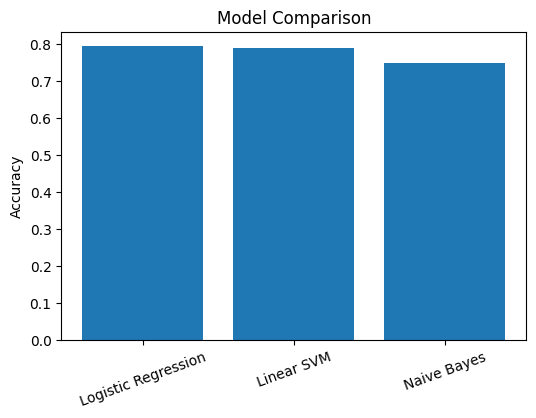

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

### Insight

- Logistic Regression and Linear SVM typically perform best on TF-IDF features  
- Naive Bayes is fast but may underperform on complex patterns  
- Linear models work well for high-dimensional sparse text data  

## Confusion Matrix (Best Model)

Visualize prediction performance for the best-performing model.

Best Model: Logistic Regression


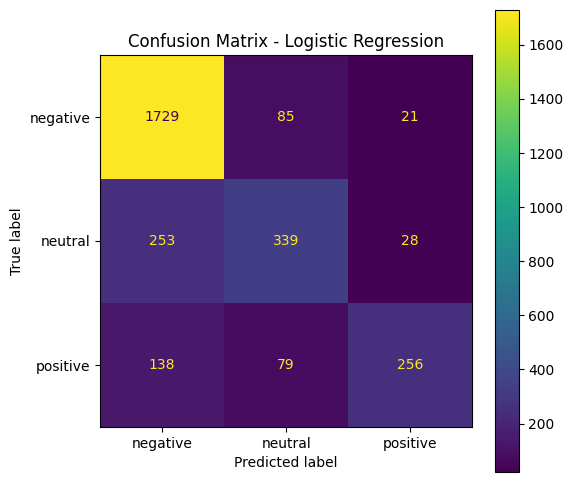

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Select best model
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]

print("Best Model:", best_model_name)

# Compute confusion matrix
cm = confusion_matrix(y_test, best_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## Key Findings

- Linear models performed strongly on TF-IDF features  
- The dataset shows class imbalance, affecting recall for minority classes  
- Most errors occur between neutral and negative sentiments  

## Conclusion (Baseline Models)

Baseline machine learning models provide strong performance for sentiment classification using TF-IDF features.

Among the models tested:

- Logistic Regression and Linear SVM achieved the best performance  
- Naive Bayes offered fast training but lower accuracy  

These results establish a solid baseline before exploring deep learning models such as LSTM or Transformers.